# Tutorial: The No-Cloning Theorem

## Overview

The **no-cloning theorem** is one of the most fundamental results in quantum information
theory (Wootters & Zurek, 1982 [1]). It states:

> *There is no unitary operation that can produce an identical copy of an arbitrary,
> unknown quantum state.*

This follows directly from the **linearity** of quantum mechanics and has profound
implications: it rules out simple error correction by copying qubits (motivating
the entire field of QEC), and it underlies the security of quantum key distribution.

**In this tutorial we:**

| Step | Action |
|---|---|
| 1 | Prepare an arbitrary state $|\psi\rangle = R_Y(\theta)|0\rangle$ |
| 2 | Build a CNOT-based "copy" attempt $\mathtt{qc\_c}$ |
| 3 | Build a true independent preparation $\mathtt{qc\_d}$ |
| 4 | Show that 1-qubit sampling **cannot** distinguish them |
| 5 | Use an **inverse test** to reveal the copy failure |

**Prerequisites:** Basic Qiskit, Dirac notation, single-qubit gates.

---

**References:**

| # | Reference |
|---|---|
| [1] | Wootters, W. K. & Zurek, W. H. A single quantum cannot be cloned. *Nature* **299**, 802 (1982). |
| [2] | Dieks, D. Communication by EPR devices. *Phys. Lett. A* **92**, 271 (1982). |
| [3] | Nielsen & Chuang. *Quantum Computation and Quantum Information*. Cambridge, 2010. Ch. 12. |
| [4] | Qiskit docs: https://docs.quantum.ibm.com |


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector
from qiskit.visualization import plot_histogram

plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})
print('Imports successful.')

Imports successful.


---
## 1. The Original State

We prepare an arbitrary single-qubit state using the $R_Y(\theta)$ rotation gate:

$$R_Y(\theta) = \begin{pmatrix} \cos(\theta/2) & -\sin(\theta/2) \\
\sin(\theta/2) & \cos(\theta/2) \end{pmatrix}$$

Applied to $|0\rangle$:
$$|\psi\rangle = R_Y(\theta)|0\rangle
= \cos\tfrac{\theta}{2}|0\rangle + \sin\tfrac{\theta}{2}|1\rangle$$

With $\theta = \pi/3$ we get $|\psi\rangle = \frac{\sqrt{3}}{2}|0\rangle + \frac{1}{2}|1\rangle$,
a non-trivial superposition with $P(0) = 3/4$, $P(1) = 1/4$.
The choice is arbitrary — the theorem holds for any $\theta$.


theta = pi/3
  cos(theta/2) = 0.8660,   sin(theta/2) = 0.5000
  |psi> = 0.8660|0> + 0.5000|1>
  P(0) = 0.7500,  P(1) = 0.2500

Original state circuit:


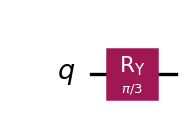

In [3]:
theta = np.pi / 3
c, s = np.cos(theta / 2), np.sin(theta / 2)
print(f'theta = pi/3')
print(f'  cos(theta/2) = {c:.4f},   sin(theta/2) = {s:.4f}')
print(f'  |psi> = {c:.4f}|0> + {s:.4f}|1>')
print(f'  P(0) = {c**2:.4f},  P(1) = {s**2:.4f}')

# Build and display the original state circuit
qc_orig = QuantumCircuit(1, name='|psi>')
qc_orig.ry(theta, 0)
print()
print('Original state circuit:')
qc_orig.draw(output='mpl')

In [4]:
# Display the statevector
Statevector(qc_orig).draw('latex')

<IPython.core.display.Latex object>

---
## 2. Two Approaches to 'Copying'

### Approach A — CNOT 'copy' ($\mathtt{qc\_c}$)

Use the source qubit ($q_1$ in state $|\psi\rangle$) as the CNOT control and
an ancilla ($q_0 = |0\rangle$) as the target:

$$\text{CNOT}\,(|\psi\rangle_{q_1}|0\rangle_{q_0})
= \text{CNOT}\,\bigl(\cos\tfrac{\theta}{2}|{10}\rangle + \sin\tfrac{\theta}{2}|{00}\rangle\bigr)
= \cos\tfrac{\theta}{2}|{11}\rangle + \sin\tfrac{\theta}{2}|{00}\rangle$$

This is an **entangled Bell-like state** — not the product state
$|\psi\rangle\otimes|\psi\rangle$ that a copier must produce.

### Approach B — Independent preparation ($\mathtt{qc\_d}$)

Apply $R_Y(\theta)$ independently to both qubits to produce the
**true product state** (cheating — requires knowing $\theta$):

$$|\psi\rangle\otimes|\psi\rangle
= \cos^2\tfrac{\theta}{2}|{00}\rangle
+ \cos\tfrac{\theta}{2}\sin\tfrac{\theta}{2}|{01}\rangle
+ \sin\tfrac{\theta}{2}\cos\tfrac{\theta}{2}|{10}\rangle
+ \sin^2\tfrac{\theta}{2}|{11}\rangle$$

In a real scenario we would not know $\theta$, so this approach is not achievable
by a universal cloner. It serves as the benchmark for what a perfect copy looks like.


qc_c — CNOT approach:


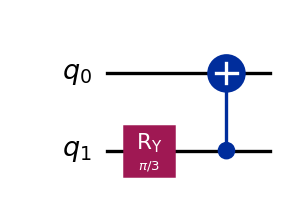

In [5]:
# ── Approach A: CNOT 'copy' ─────────────────────────────────────────────
qc_c = QuantumCircuit(2, name='qc_c')
qc_c.ry(theta, 1)   # prepare source qubit q1 in |psi>
qc_c.cx(1, 0)       # CNOT: q1 = control, q0 = target
print('qc_c — CNOT approach:')
qc_c.draw(output='mpl')

In [6]:
sv_c = Statevector(qc_c)
print('Statevector of qc_c (CNOT approach):')
sv_c.draw('latex')

Statevector of qc_c (CNOT approach):


<IPython.core.display.Latex object>

qc_d — independent preparation:


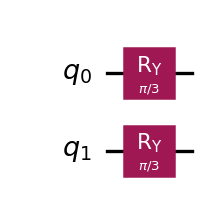

In [7]:
# ── Approach B: independent preparation ────────────────────────────────
qc_d = QuantumCircuit(2, name='qc_d')
qc_d.ry(theta, 1)   # q1 in |psi>
qc_d.ry(theta, 0)   # q0 independently in |psi> (requires knowing theta!)
print('qc_d — independent preparation:')
qc_d.draw(output='mpl')

In [8]:
sv_d = Statevector(qc_d)
print('Statevector of qc_d (independent preparation):')
sv_d.draw('latex')

Statevector of qc_d (independent preparation):


<IPython.core.display.Latex object>

---
## 3. First Comparison: Sampling $q_0$ Alone

We sample only qubit $q_0$ (the 'copy' qubit) from both circuits.
This gives the **marginal distribution** — it ignores correlations.

For both circuits, the reduced state of $q_0$ has:
$$P(q_0 = 0) = \cos^2\tfrac{\theta}{2} = \tfrac{3}{4}, \qquad
P(q_0 = 1) = \sin^2\tfrac{\theta}{2} = \tfrac{1}{4}$$

> **Key insight:** One-qubit marginal sampling gives **identical results** for
> the entangled state and the true product state. Looking at $q_0$ alone, we
> cannot tell whether copying succeeded. We need a smarter test.


qc_c  q0 counts (2000 shots): {np.str_('0'): np.int64(1494), np.str_('1'): np.int64(506)}
qc_d  q0 counts (2000 shots): {np.str_('0'): np.int64(1471), np.str_('1'): np.int64(529)}

Analytical: P(0) = 0.7500 = 3/4,  P(1) = 0.2500 = 1/4
=> Marginal distributions are identical.
   1-qubit sampling CANNOT distinguish a CNOT entangled state from a true copy.


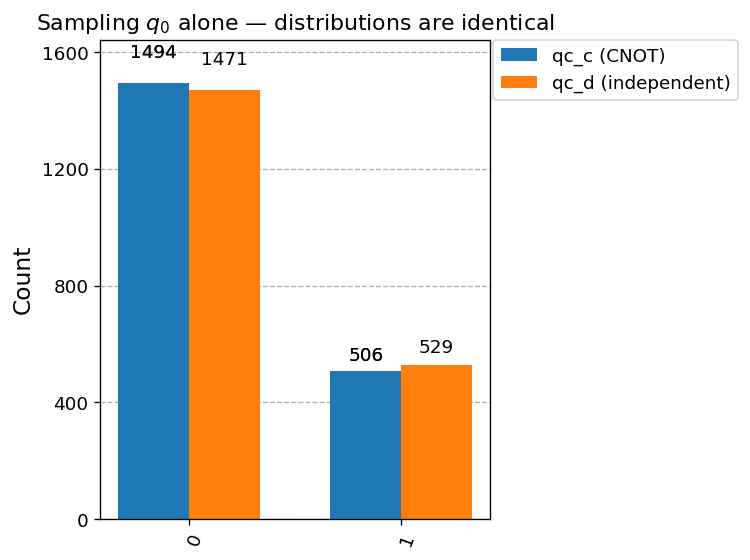

In [13]:
# Sample qubit 0 (index 0) from both state vectors
c_counts = sv_c.sample_counts(2000, [0])
d_counts = sv_d.sample_counts(2000, [0])

print(f'qc_c  q0 counts (2000 shots): {dict(sorted(c_counts.items()))}')
print(f'qc_d  q0 counts (2000 shots): {dict(sorted(d_counts.items()))}')
print()
print(f'Analytical: P(0) = {c**2:.4f} = 3/4,  P(1) = {s**2:.4f} = 1/4')
print('=> Marginal distributions are identical.')
print('   1-qubit sampling CANNOT distinguish a CNOT entangled state from a true copy.')

plot_histogram(
    [c_counts, d_counts],
    legend=['qc_c (CNOT)', 'qc_d (independent)'],
    title=r'Sampling $q_0$ alone — distributions are identical'
)
#plt.show()

---
## 4. The Inverse Test

We now apply $R_Y(-\theta)$ — the inverse rotation — to $q_0$.

**Reasoning:** If the copy was perfect, then $q_0$ is in state
$|\psi\rangle = R_Y(\theta)|0\rangle$, and:
$$R_Y(-\theta)|\psi\rangle = R_Y(-\theta)R_Y(\theta)|0\rangle = |0\rangle$$
We should measure $q_0 = 0$ with probability 1.

**$\mathtt{qc\_d}$ (true product state):** $q_0$ is exactly in $|\psi\rangle$,
so $R_Y(-\theta)$ returns it to $|0\rangle$ with certainty: $P(q_0{=}0) = 1$.

**$\mathtt{qc\_c}$ (CNOT entangled state):** $q_0$ is **not** in a definite
state $|\psi\rangle$ — it is entangled with $q_1$. After $R_Y(-\theta)$ on $q_0$:

$$P_{\mathtt{qc\_c}}(q_0{=}0)
= \cos^4\tfrac{\theta}{2} + \sin^4\tfrac{\theta}{2}
= 1 - \tfrac{\sin^2\theta}{2}
= \frac{5}{8} \neq 1$$

For $\theta = \pi/3$: $1 - \sin^2(\pi/3)/2 = 1 - 3/8 = 5/8 = 0.625$.
This confirms that the CNOT did **not** clone the state.


qc_c + inverse rotation on q0:


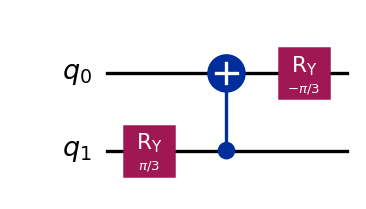

In [10]:
# ── qc_c + inverse: RY(-theta) applied to q0 ────────────────────────────
qc_c_inv = QuantumCircuit(2, name='qc_c + inv')
qc_c_inv.ry(theta, 1)
qc_c_inv.cx(1, 0)
qc_c_inv.ry(-theta, 0)    # ry(-theta) = RY(theta).inverse()
print('qc_c + inverse rotation on q0:')
qc_c_inv.draw(output='mpl')

qc_d + inverse rotation on q0:


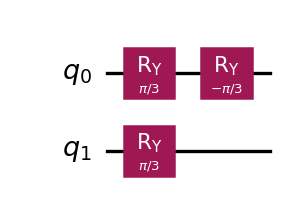

In [11]:
# ── qc_d + inverse: RY(-theta) applied to q0 ────────────────────────────
qc_d_inv = QuantumCircuit(2, name='qc_d + inv')
qc_d_inv.ry(theta, 1)
qc_d_inv.ry(theta, 0)
qc_d_inv.ry(-theta, 0)    # cancels the RY(theta) on q0: net = identity on q0
print('qc_d + inverse rotation on q0:')
qc_d_inv.draw(output='mpl')

After applying RY(-theta) to q0:
  qc_c counts: {np.str_('0'): np.int64(1261), np.str_('1'): np.int64(739)}
  qc_d counts: {np.str_('0'): np.int64(2000)}

Theory: qc_c P(q0=0) = cos^4 + sin^4 = 0.6250 (should be < 1.0)
Theory: qc_d P(q0=0) = 1.0000 exactly

=> CNOT copy: P(q0=0) = 0.625 -- copy FAILED
=> True copy: P(q0=0) = 1.000 -- state recovered perfectly


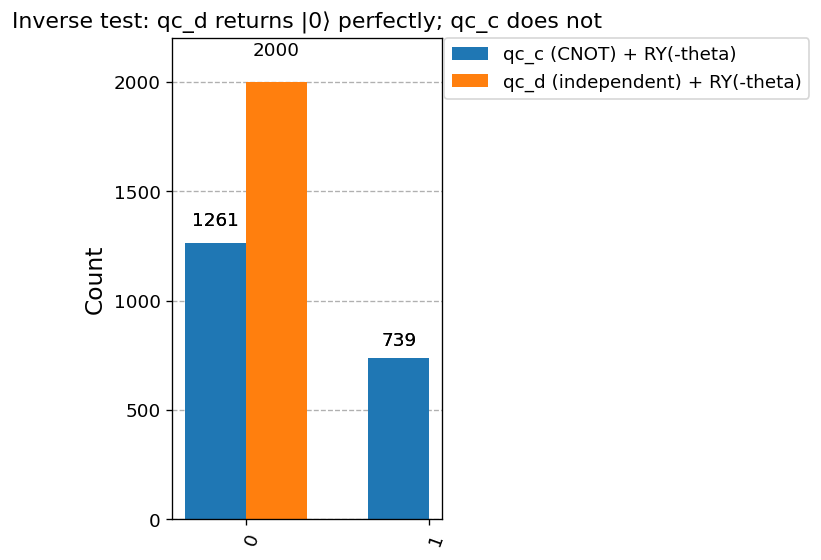

In [14]:
sv_c_inv = Statevector(qc_c_inv)
sv_d_inv = Statevector(qc_d_inv)

c_inv_counts = sv_c_inv.sample_counts(2000, [0])
d_inv_counts = sv_d_inv.sample_counts(2000, [0])

p_theory = c**4 + s**4     # = 1 - sin^2(theta)/2 = 5/8 for theta=pi/3

print('After applying RY(-theta) to q0:')
print(f'  qc_c counts: {dict(sorted(c_inv_counts.items()))}')
print(f'  qc_d counts: {dict(sorted(d_inv_counts.items()))}')
print()
print(f'Theory: qc_c P(q0=0) = cos^4 + sin^4 = {p_theory:.4f} (should be < 1.0)')
print(f'Theory: qc_d P(q0=0) = 1.0000 exactly')
print()
print('=> CNOT copy: P(q0=0) = 0.625 -- copy FAILED')
print('=> True copy: P(q0=0) = 1.000 -- state recovered perfectly')

plot_histogram(
    [c_inv_counts, d_inv_counts],
    legend=['qc_c (CNOT) + RY(-theta)', 'qc_d (independent) + RY(-theta)'],
    title='Inverse test: qc_d returns |0⟩ perfectly; qc_c does not'
)
#plt.show()

---
## 5. Why No Unitary Can Clone — Proof Sketch

Suppose a unitary $U$ could clone any state:
$$U|\psi\rangle|0\rangle = |\psi\rangle|\psi\rangle \quad \forall\,|\psi\rangle$$

Apply this to two states $|\psi\rangle$ and $|\phi\rangle$, then take the
inner product of both sides. Since $U$ is unitary (preserves inner products):

$$\langle\psi|\phi\rangle\underbrace{\langle 0|0\rangle}_{=1}
= \langle\psi|\phi\rangle^2$$

This equation $x = x^2$ holds only for $x = 0$ or $x = 1$.
For any state $|\phi\rangle$ that is neither identical nor orthogonal to $|\psi\rangle$
— e.g. $|\psi\rangle = |0\rangle$, $|\phi\rangle = |{+}\rangle$ where
$\langle\psi|\phi\rangle = 1/\sqrt{2}$ — we have a contradiction. $\square$

**What CNOT actually does to superpositions:**

| Input | After CNOT | Is it $|\psi\rangle\otimes|\psi\rangle$? |
|---|---|---|
| $|0\rangle_{q_1}|0\rangle_{q_0}$ | $|00\rangle$ | ✓ (trivially) |
| $|1\rangle_{q_1}|0\rangle_{q_0}$ | $|11\rangle$ | ✓ (trivially) |
| $(\alpha|0\rangle+\beta|1\rangle)|0\rangle$ | $\alpha|00\rangle+\beta|11\rangle$ | **✗ Entangled** |

CNOT copies the *computational basis states* $|0\rangle$ and $|1\rangle$ correctly,
but creates entanglement for any superposition. Entanglement $\neq$ cloning.

---
## Summary

| Test | $\mathtt{qc\_c}$ (CNOT) | $\mathtt{qc\_d}$ (independent) | Interpretation |
|---|---|---|---|
| Marginal sampling $q_0$ | $P(0) = 3/4$ | $P(0) = 3/4$ | Identical — cannot detect failure |
| Inverse test | $P(q_0{=}0) = 5/8$ | $P(q_0{=}0) = 1$ | CNOT failed — produced entanglement |
| Full state | Entangled | Product | Fundamentally different |

The no-cloning theorem is not just a limitation to work around — it is a **physical
resource**: it guarantees that quantum information cannot be intercepted by copying,
which is the security foundation of quantum cryptography. In the context of quantum
error correction, it forces the use of *entanglement-based redundancy* (stabilizer codes)
rather than classical repetition.
